# 🎓 Project: Financial Market Analysis of AI Companies

**Hello friends! Welcome to this hands-on tutorial.**

In this section, we will examine the **Artificial Intelligence (AI)** sector, the hottest competition area of today's technology, in the light of financial data. Using synthetic data from tech giants like OpenAI, Google, and Meta, we will conduct a comprehensive analysis ranging from R&D expenses to stock market impacts and the market reflections of critical technological events.

### 🎯 What Will We Learn in This Project?
Throughout this data analysis project, we will seek answers to the following questions and gain these competencies:

1.  **Data Exploration and Cleaning:** How do we process raw data with `pandas` and convert it into Time-Series format?
2.  **Financial Comparison:** Which company invests more in R&D? What is the conversion rate of investments to revenue?
3.  **Event Study:** How did major events like the *release of GPT-4* or *TensorFlow* affect company stocks?
4.  **Visualization:** How do we transform complex financial data into understandable charts (Bar chart, Line plot, Heatmap) using `Matplotlib` and `Seaborn`?
5.  **Correlation Analysis:** Is there a statistical relationship between spending and stock growth?

### 🛠️ Libraries Used
* **Pandas:** Data manipulation and analysis.
* **Matplotlib & Seaborn:** Data visualization and plotting.



## 1. Loading Libraries and Reading the Dataset
Libraries required for data analysis and visualization (Pandas, Seaborn, Matplotlib) are imported, and the dataset is loaded.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:

df =pd.read_csv("market_data.csv")
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


# 2. Data Preprocessing and Historical Features
We convert the `Date` column to datetime format and add "Year" information as a new column for use in analysis. We also check the companies and significant events (e.g., GPT-4 release) in the dataset. We also check for missing data at this stage.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"]

0       2015-01-01
1       2015-01-02
2       2015-01-03
3       2015-01-04
4       2015-01-05
           ...    
10954   2024-12-27
10955   2024-12-28
10956   2024-12-29
10957   2024-12-30
10958   2024-12-31
Name: Date, Length: 10959, dtype: datetime64[ns]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [6]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41


In [7]:
df["Year"] = df["Date"].dt.year

In [8]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [9]:
df["Event"].unique()

array([nan, 'Cloud AI launch', 'AI ethics policy update',
       'AI-powered search update', 'AI Ads Optimization upgrade',
       'AI partnership deal', 'AI Video Recommendation upgrade',
       'AI speech recognition release', 'GPT-1 release', 'GPT-2 release',
       'GPT-3 release', 'Codex release', 'DALL·E 2 release',
       'ChatGPT (GPT-3.5) launch', 'GPT-4 release',
       'GPT-5 release (predicted)', 'TensorFlow open-source release',
       'AlphaGo beats Lee Sedol', 'BERT for Search launch',
       'MUM Search Model launch', 'Bard chatbot launch',
       'Gemini AI release', 'LLaMA 1 release', 'LLaMA 2 release',
       'LLaMA 3 release (predicted)'], dtype=object)

In [10]:
df[df["Event"] == "GPT-4 release"]

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.2,2023


In [11]:
df.isnull().sum()

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
Year                       0
dtype: int64

# 3. R&D Spending and Revenue Comparison by Company
We calculate the total R&D spending and AI Revenue for each company. We then visualize these two metrics (Expenditure vs. Revenue) with side-by-side charts to get an overview of the companies' financial performance.

In [12]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [13]:
RD= df.groupby("Company")["R&D_Spending_USD_Mn"].sum() /1000 #Billion $
RD

Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

In [14]:
RD.reset_index()

,Company,R&D_Spending_USD_Mn
0,Google,423.34114
1,Meta,264.53307
2,OpenAI,26.48277


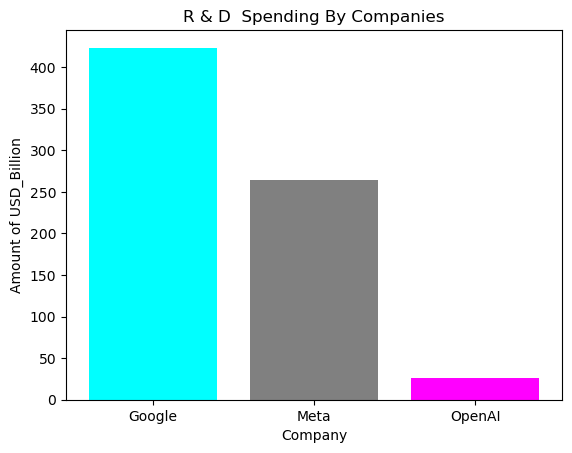

In [15]:
plt.bar(RD.index,RD.values,color =["cyan","grey","magenta"])
plt.title("R & D  Spending By Companies")
plt.xlabel("Company")
plt.ylabel("Amount of USD_Billion")
plt.show()

In [16]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [17]:
print("Company's AI_Revenue_USD_Mn:")
revenue = df.groupby("Company")["AI_Revenue_USD_Mn"].sum()
revenue

Company's AI_Revenue_USD_Mn:


Company
Google    284498.38
Meta      189621.82
OpenAI      9462.89
Name: AI_Revenue_USD_Mn, dtype: float64

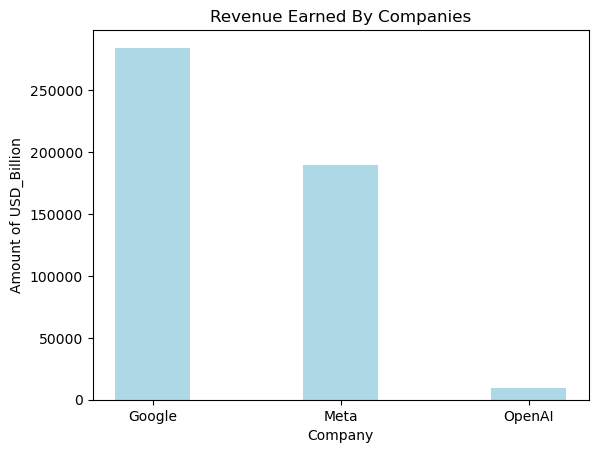

In [18]:
plt.bar(revenue.index, revenue.values,color="lightblue",width=0.4)
plt.title("Revenue Earned By Companies")
plt.xlabel("Company")
plt.ylabel("Amount of USD_Billion")
plt.show()

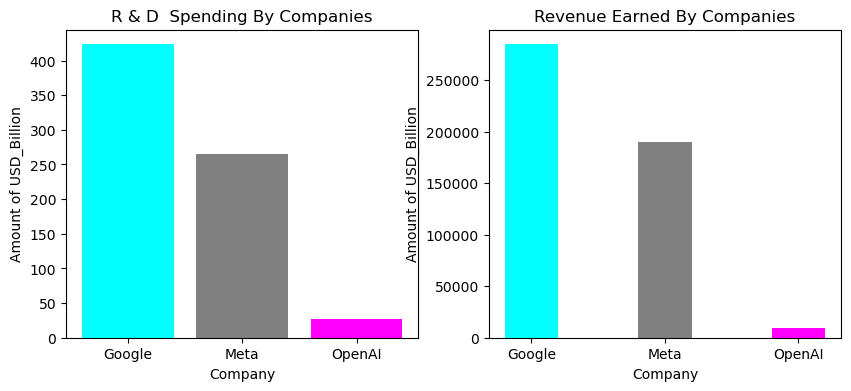

In [19]:
plt.figure(figsize =(10,4))
plt.subplot(1,2,1)

plt.bar(RD.index,RD.values,color =["cyan","grey","magenta"])
plt.title("R & D  Spending By Companies")
plt.xlabel("Company")
plt.ylabel("Amount of USD_Billion")

plt.subplot(1,2,2)
plt.bar(revenue.index, revenue.values,color=["cyan","grey","magenta"],width=0.4)
plt.title("Revenue Earned By Companies")
plt.xlabel("Company")
plt.ylabel("Amount of USD_Billion")

plt.show()



# 4. General Trend in Stock Values
We visualize the stock market impacts (`Stock_Impact_%`) across the entire date range using a line chart to examine the general trend.

In [20]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


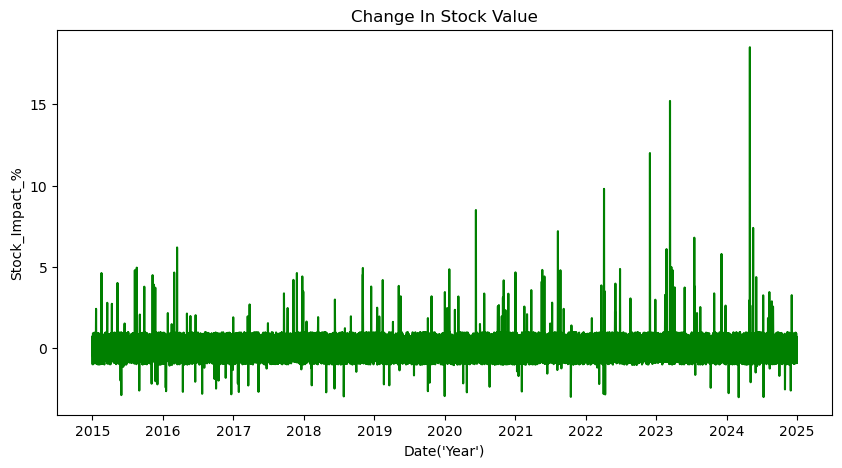

In [21]:
plt.figure(figsize= (10,5))

plt.plot(df["Date"], df["Stock_Impact_%"],color="green")
plt.title("Change In Stock Value")
plt.xlabel("Date('Year')")
plt.ylabel("Stock_Impact_%")
plt.show()

# 5. Filtering Data by Company
To conduct a more detailed analysis, we split the main dataset by company (OpenAI, Google, Meta) and create separate DataFrames for each.

In [22]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [23]:
df["Company"].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [24]:
data_openAI = df[df["Company"]== "OpenAI"]
data_openAI


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93,2024
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25,2024
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47,2024
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69,2024


In [25]:
data_Google = df[df["Company"]== "Google"]
data_Google

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3653,2015-01-01,Google,79.89,30.19,0.64,NaN,-0.02,2015
3654,2015-01-02,Google,78.99,30.44,1.47,NaN,-0.98,2015
3655,2015-01-03,Google,79.20,30.46,1.53,NaN,0.78,2015
3656,2015-01-04,Google,79.59,30.55,1.82,NaN,-0.41,2015
3657,2015-01-05,Google,81.50,30.59,1.97,NaN,-0.78,2015
...,...,...,...,...,...,...,...,...
7301,2024-12-27,Google,162.16,155.36,417.88,NaN,-0.46,2024
7302,2024-12-28,Google,159.69,154.47,414.89,NaN,-0.48,2024
7303,2024-12-29,Google,161.69,154.59,415.31,NaN,0.72,2024
7304,2024-12-30,Google,158.48,155.05,416.84,NaN,-0.17,2024


In [26]:
data_Meta = df[df["Company"]== "Meta"]
data_Meta

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
7306,2015-01-01,Meta,50.39,18.95,-5.23,NaN,-0.42,2015
7307,2015-01-02,Meta,49.80,19.77,-1.16,NaN,0.63,2015
7308,2015-01-03,Meta,49.09,19.96,-0.21,NaN,0.73,2015
7309,2015-01-04,Meta,50.66,20.48,2.38,NaN,-0.26,2015
7310,2015-01-05,Meta,51.36,19.84,-0.80,NaN,-0.37,2015
...,...,...,...,...,...,...,...,...
10954,2024-12-27,Meta,100.19,103.54,417.68,NaN,-0.66,2024
10955,2024-12-28,Meta,99.12,102.37,411.86,NaN,-0.57,2024
10956,2024-12-29,Meta,98.95,103.11,415.54,NaN,-0.52,2024
10957,2024-12-30,Meta,100.74,103.21,416.03,NaN,0.22,2024


# 6. Visualizing Company Stock Performance
Using the separated data, we plot the stock change graph for each company. Finally, using `subplot`, we place the charts of the three companies side-by-side to compare their performances.

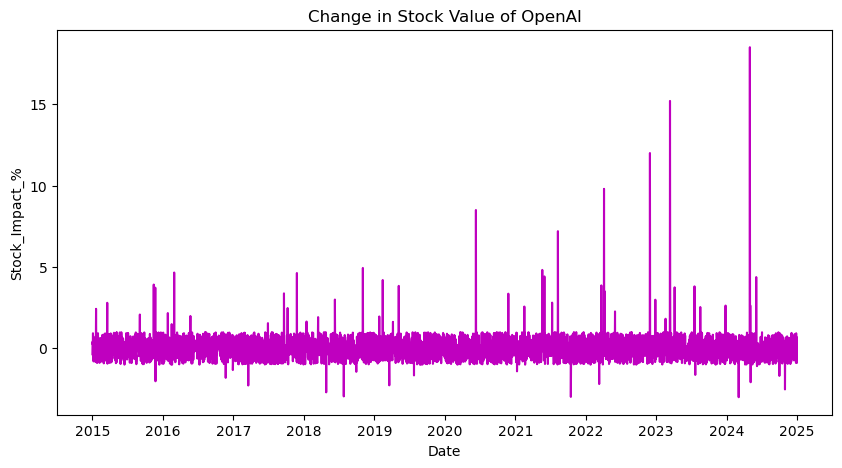

In [27]:
plt.figure(figsize=(10,5))
plt.plot(data_openAI["Date"],data_openAI["Stock_Impact_%"],color="m")

plt.title("Change in Stock Value of OpenAI")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")

plt.show()

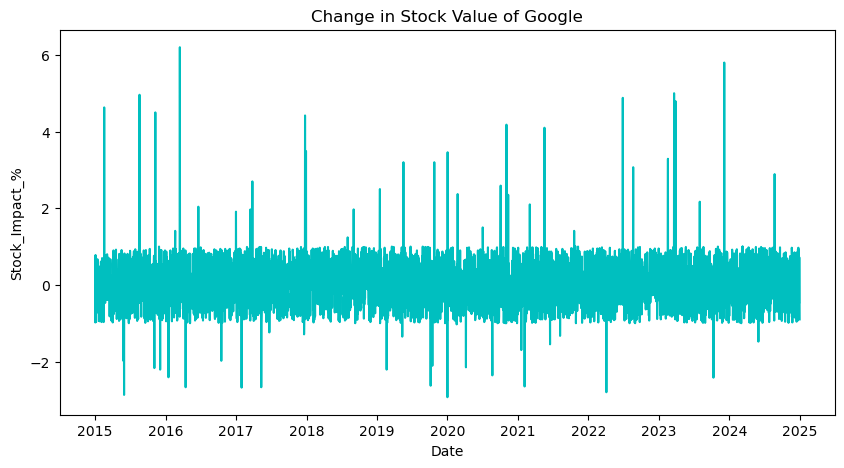

In [28]:
plt.figure(figsize=(10,5))
plt.plot(data_Google["Date"],data_Google["Stock_Impact_%"],color="c")

plt.title("Change in Stock Value of Google")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")

plt.show()

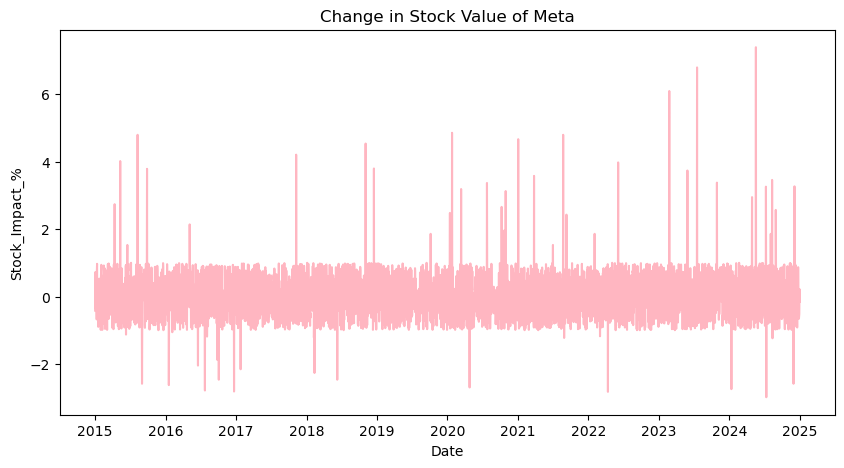

In [29]:
plt.figure(figsize=(10,5))
plt.plot(data_Meta["Date"],data_Meta["Stock_Impact_%"],color="lightpink")

plt.title("Change in Stock Value of Meta")
plt.xlabel("Date")
plt.ylabel("Stock_Impact_%")

plt.show()

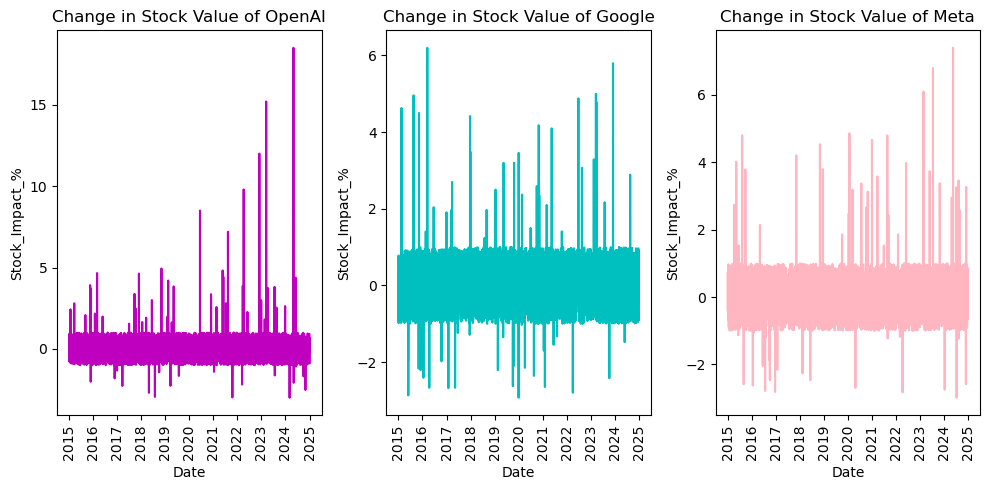

In [30]:
plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)

plt.plot(data_openAI["Date"],data_openAI["Stock_Impact_%"],color="m")
plt.title("Change in Stock Value of OpenAI")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Stock_Impact_%")


plt.subplot(1,3,2)

plt.plot(data_Google["Date"],data_Google["Stock_Impact_%"],color="c")
plt.title("Change in Stock Value of Google")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Stock_Impact_%")

plt.subplot(1,3,3)

plt.plot(data_Meta["Date"],data_Meta["Stock_Impact_%"],color="lightpink")
plt.title("Change in Stock Value of Meta")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Stock_Impact_%")

plt.tight_layout() #grafikleirn arasını açar
plt.show()

# 7. Ranking by Stock Market Impact
We sort the data for each company based on `Stock_Impact_%` in descending order to identify the most critical dates for the companies.

In [31]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [32]:
data_openAI.sort_values(by="Stock_Impact_%",ascending =False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3408,2024-05-01,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.50,2024
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.20,2023
2890,2022-11-30,OpenAI,10.60,3.18,217.72,ChatGPT (GPT-3.5) launch,12.00,2022
2652,2022-04-06,OpenAI,9.24,3.48,247.93,DALL·E 2 release,9.80,2022
1988,2020-06-11,OpenAI,5.90,2.62,161.56,GPT-3 release,8.50,2020
...,...,...,...,...,...,...,...,...
3590,2024-10-30,OpenAI,11.05,5.27,427.50,AI-powered search update,-2.52,2024
1212,2018-04-27,OpenAI,5.38,1.76,76.47,AI ethics policy update,-2.70,2018
1303,2018-07-27,OpenAI,7.44,0.97,-2.63,AI-powered search update,-2.95,2018
2480,2021-10-16,OpenAI,8.39,2.78,178.28,AI Ads Optimization upgrade,-2.98,2021


In [33]:
data_Google.sort_values(by="Stock_Impact_%",ascending =False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
4092,2016-03-15,Google,84.56,36.22,20.73,AlphaGo beats Lee Sedol,6.20,2016
6914,2023-12-06,Google,146.59,129.17,330.55,Gemini AI release,5.80,2023
6654,2023-03-21,Google,149.34,129.76,332.53,Bard chatbot launch,5.00,2023
3883,2015-08-19,Google,79.27,30.89,2.98,AI partnership deal,4.96,2015
6388,2022-06-28,Google,137.71,107.96,259.85,AI ethics policy update,4.88,2022
...,...,...,...,...,...,...,...,...
4122,2016-04-14,Google,87.19,36.08,20.28,AI partnership deal,-2.67,2016
4412,2017-01-29,Google,92.21,43.25,44.17,AI Ads Optimization upgrade,-2.68,2017
6303,2022-04-04,Google,138.00,106.81,256.04,AI Video Recommendation upgrade,-2.80,2022
3803,2015-05-31,Google,81.14,29.30,-2.32,Cloud AI launch,-2.87,2015


In [34]:
data_Meta.sort_values(by="Stock_Impact_%",ascending =False)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
10731,2024-05-18,Meta,103.64,103.05,415.23,LLaMA 3 release (predicted),7.40,2024
10426,2023-07-18,Meta,92.44,85.67,328.37,LLaMA 2 release,6.80,2023
10282,2023-02-24,Meta,93.71,86.98,334.89,LLaMA 1 release,6.10,2023
9156,2020-01-25,Meta,72.73,49.10,145.49,Cloud AI launch,4.86,2020
7526,2015-08-09,Meta,48.97,19.95,-0.27,AI Video Recommendation upgrade,4.80,2015
...,...,...,...,...,...,...,...,...
10604,2024-01-12,Meta,99.37,104.28,421.42,AI Video Recommendation upgrade,-2.75,2024
7875,2016-07-23,Meta,53.76,23.97,19.83,AI-powered search update,-2.79,2016
8026,2016-12-21,Meta,53.18,23.42,17.11,AI-powered search update,-2.82,2016
9964,2022-04-12,Meta,84.90,71.99,259.95,AI ethics policy update,-2.83,2022


# 8. AI Revenue Growth Analysis
We examine the growth rates of companies' AI revenues. After looking at the general distribution with a `scatterplot`, we visualize the growth trend of each company separately with line charts.

In [35]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [36]:
df.groupby("Company")["AI_Revenue_Growth_%"].sum()

Company
Google    583027.25
Meta      582807.74
OpenAI    580985.64
Name: AI_Revenue_Growth_%, dtype: float64

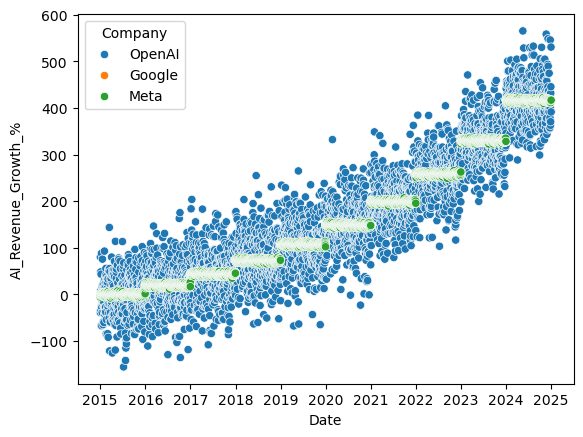

In [37]:
sns.scatterplot(x="Date",y="AI_Revenue_Growth_%",data=df,hue="Company")
plt.show()

In [38]:
df.sort_values(by=["AI_Revenue_Growth_%"])

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
189,2015-07-09,OpenAI,5.66,-0.55,-155.43,NaN,0.70,2015
205,2015-07-25,OpenAI,5.23,-0.42,-141.61,NaN,-0.62,2015
649,2016-10-11,OpenAI,5.37,-0.35,-135.31,NaN,0.12,2016
548,2016-07-02,OpenAI,5.19,-0.29,-129.11,NaN,-0.31,2016
98,2015-04-09,OpenAI,4.80,-0.25,-125.50,NaN,-0.56,2015
...,...,...,...,...,...,...,...,...
3508,2024-08-09,OpenAI,9.92,6.33,532.86,NaN,0.77,2024
3645,2024-12-24,OpenAI,8.79,6.46,546.07,NaN,0.45,2024
3627,2024-12-06,OpenAI,8.51,6.49,548.83,NaN,-0.15,2024
3612,2024-11-21,OpenAI,10.16,6.59,558.70,NaN,0.63,2024


In [39]:
data_openAI

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015
...,...,...,...,...,...,...,...,...
3648,2024-12-27,OpenAI,10.06,4.71,370.69,NaN,0.93,2024
3649,2024-12-28,OpenAI,9.67,5.32,432.15,NaN,-0.25,2024
3650,2024-12-29,OpenAI,9.17,5.46,445.74,NaN,0.47,2024
3651,2024-12-30,OpenAI,10.36,6.31,530.88,NaN,0.69,2024


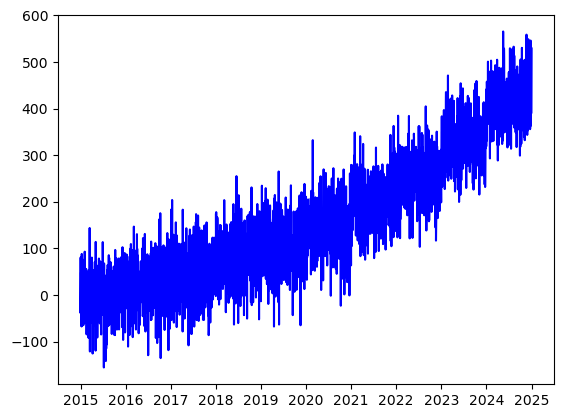

In [40]:
plt.plot(data_openAI["Date"],data_openAI["AI_Revenue_Growth_%"],color="blue")
plt.show()

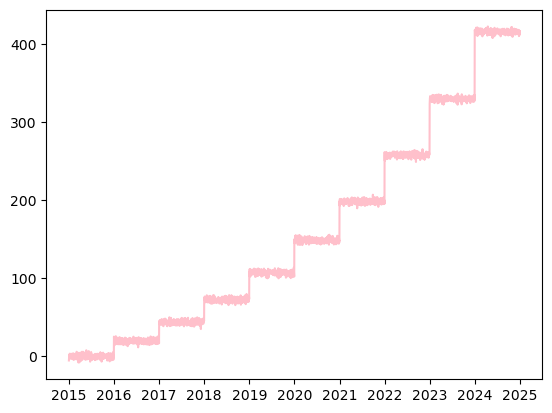

In [41]:
plt.plot(data_Meta["Date"],data_Meta["AI_Revenue_Growth_%"],color="pink")
plt.show()

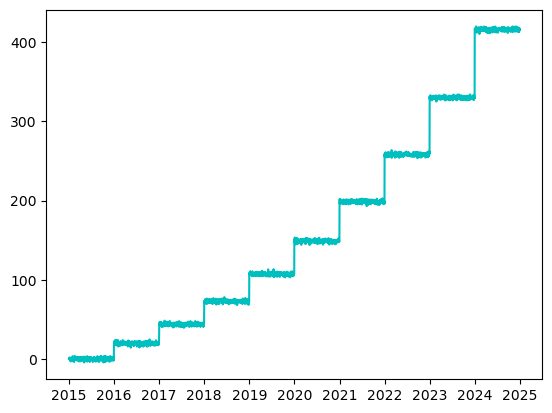

In [42]:
plt.plot(data_Google["Date"],data_Google["AI_Revenue_Growth_%"],color="c")
plt.show()

# 9. Correlation Between Variables (Heatmap)
We examine the relationship (correlation) between numerical variables in the dataset. Using a `heatmap`, we visualize which variables (e.g., R&D spending vs. Revenue) are positively or negatively related.

In [43]:
df.corr(numeric_only=True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%,Year
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628,0.297701
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017,0.526478
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937,0.952199
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000,0.016525
Year,0.297701,0.526478,0.952199,0.016525,1.000000


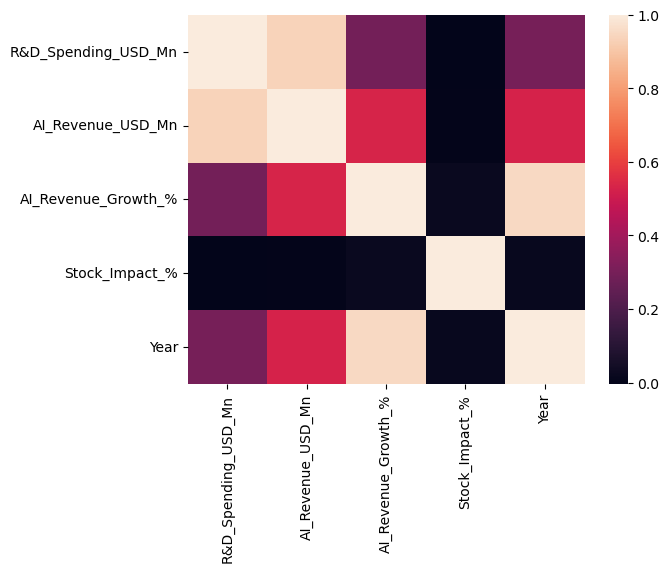

In [44]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

# 10. Annual Spending and Revenue Trends
By grouping the data by year, we examine how total R&D spending and total revenue have changed over the years. In the final chart, we plot these two metrics (Expenditure and Revenue) on the same axis to observe the profitability gap.

In [45]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [46]:
spend=df.groupby("Year")["R&D_Spending_USD_Mn"].sum()
spend

Year
2015    49304.23
2016    53349.94
2017    57475.12
2018    62002.16
2019    67071.51
2020    72602.53
2021    78207.32
2022    84390.17
2023    91193.92
2024    98760.08
Name: R&D_Spending_USD_Mn, dtype: float64

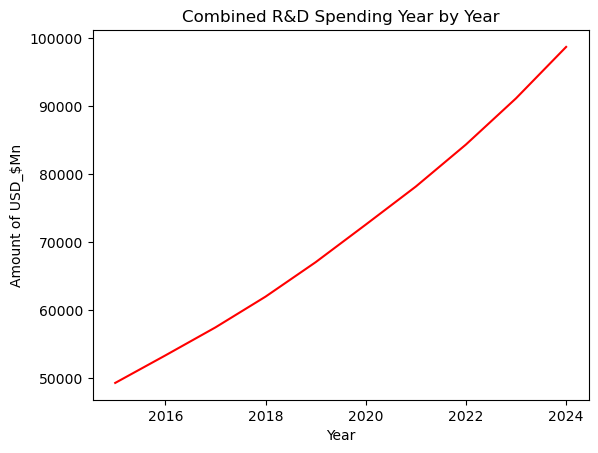

In [47]:
plt.plot(spend.index,spend.values,color="red")
plt.title("Combined R&D Spending Year by Year")
plt.xlabel("Year")
plt.ylabel("Amount of USD_$Mn")
plt.show()

In [48]:
revenue=df.groupby("Year")["AI_Revenue_USD_Mn"].sum()
revenue

Year
2015    18623.21
2016    22361.20
2017    26776.80
2018    32164.44
2019    38580.32
2020    46456.19
2021    55591.14
2022    66674.24
2023    80041.64
2024    96313.91
Name: AI_Revenue_USD_Mn, dtype: float64

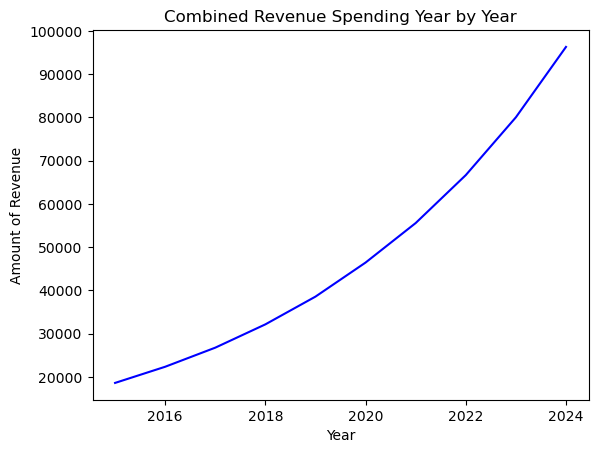

In [49]:
plt.plot(revenue.index,revenue.values,color="blue")
plt.title("Combined Revenue Spending Year by Year")
plt.xlabel("Year")
plt.ylabel("Amount of Revenue")
plt.show()

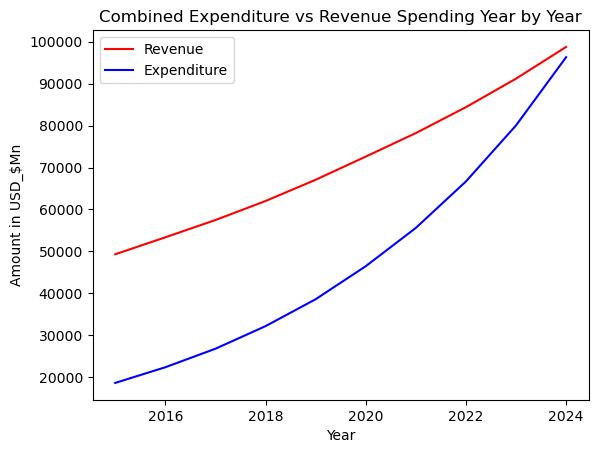

In [50]:

plt.plot(spend.index,spend.values,color="red")
plt.plot(revenue.index,revenue.values,color="blue")
plt.title("Combined Expenditure vs Revenue Spending Year by Year")
plt.xlabel("Year")
plt.ylabel("Amount in USD_$Mn")
plt.legend(["Revenue","Expenditure"])
plt.show()

# 11. Multivariate Analysis with Pairplot
We plot pairwise relationships of all numerical variables in the dataset using `pairplot` to examine the general distribution and clusters in the data.

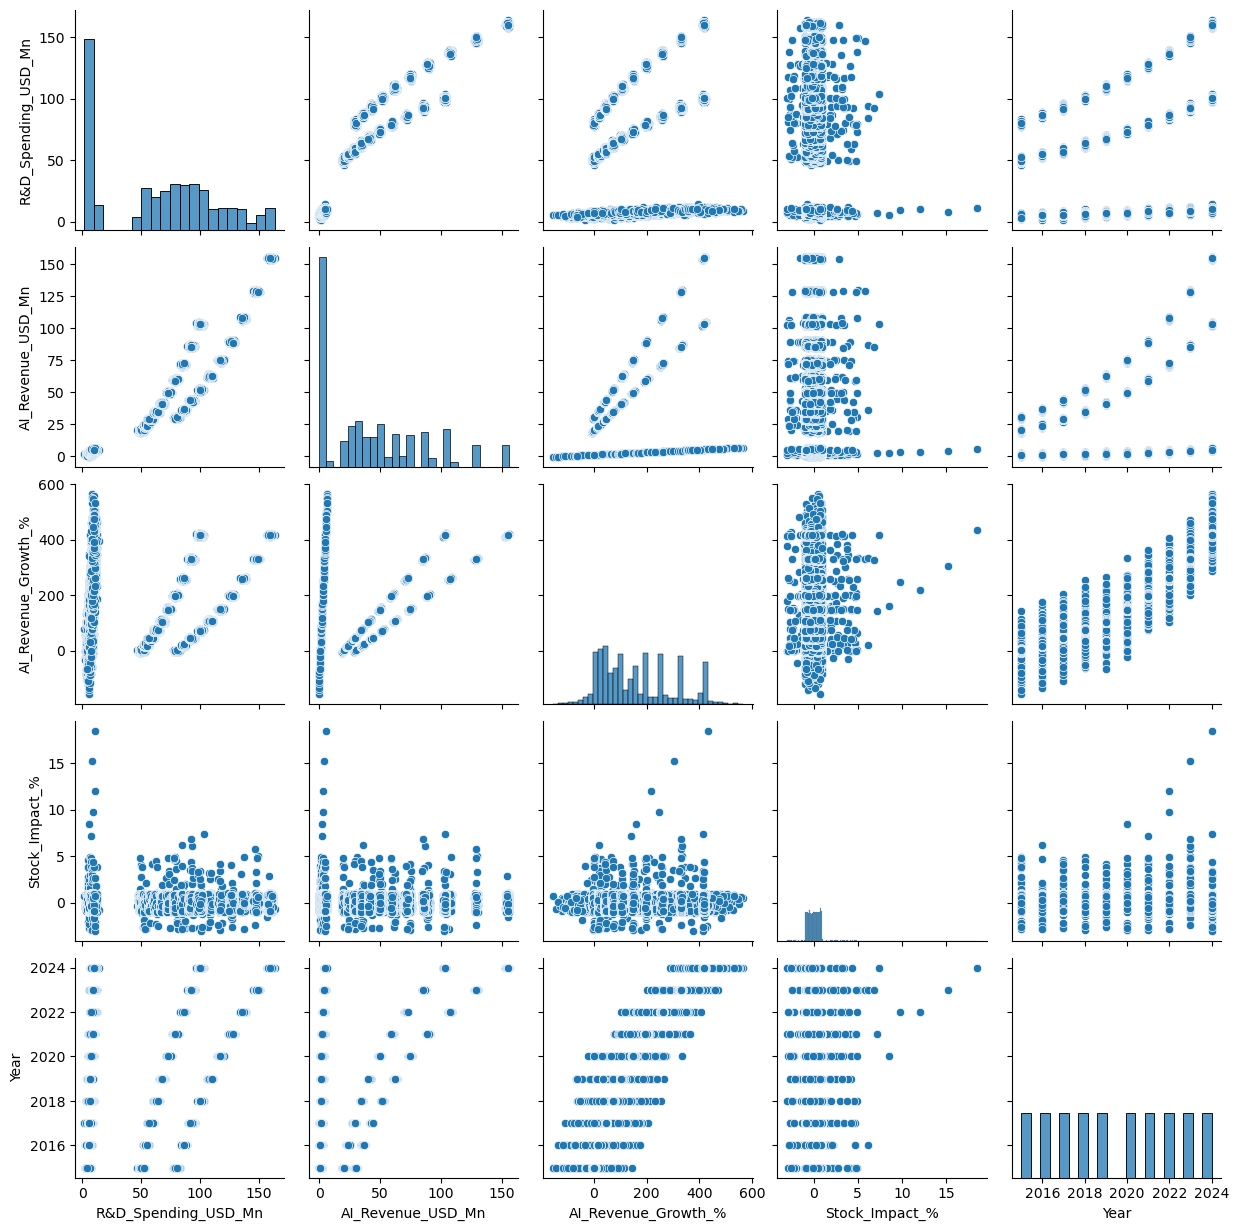

In [51]:
sns.pairplot(df)
plt.show()

# 12. Event Study: TensorFlow Release
As a special case study, we analyze the "TensorFlow open-source release" event. By filtering the date range around this event (before and after), we visualize the immediate impact of this development on stock prices.

In [52]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [53]:
df.Event.value_counts()

Event
AI speech recognition release      37
AI Ads Optimization upgrade        32
AI partnership deal                32
AI-powered search update           32
AI Video Recommendation upgrade    29
AI ethics policy update            27
Cloud AI launch                    27
GPT-1 release                       1
GPT-2 release                       1
GPT-3 release                       1
Codex release                       1
DALL·E 2 release                    1
ChatGPT (GPT-3.5) launch            1
GPT-4 release                       1
GPT-5 release (predicted)           1
TensorFlow open-source release      1
AlphaGo beats Lee Sedol             1
BERT for Search launch              1
MUM Search Model launch             1
Bard chatbot launch                 1
Gemini AI release                   1
LLaMA 1 release                     1
LLaMA 2 release                     1
LLaMA 3 release (predicted)         1
Name: count, dtype: int64

In [54]:
df[df.Event == "TensorFlow open-source release"] #checkinf for a particular event

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3965,2015-11-09,Google,79.62,29.84,-0.53,TensorFlow open-source release,4.5,2015


In [55]:
tf=df.loc[3955:3975]
tf

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
3955,2015-10-30,Google,80.33,29.87,-0.43,NaN,0.43,2015
3956,2015-10-31,Google,79.53,30.30,0.99,NaN,-0.84,2015
3957,2015-11-01,Google,80.37,29.86,-0.48,NaN,0.57,2015
3958,2015-11-02,Google,77.89,29.97,-0.10,NaN,0.76,2015
3959,2015-11-03,Google,81.00,29.43,-1.89,NaN,-0.45,2015
3960,2015-11-04,Google,80.70,29.71,-0.96,AI speech recognition release,-2.17,2015
3961,2015-11-05,Google,78.31,30.25,0.85,NaN,0.31,2015
3962,2015-11-06,Google,79.08,29.84,-0.54,NaN,-0.72,2015
3963,2015-11-07,Google,79.65,30.34,1.14,NaN,0.58,2015
3964,2015-11-08,Google,79.63,29.74,-0.86,NaN,-0.61,2015


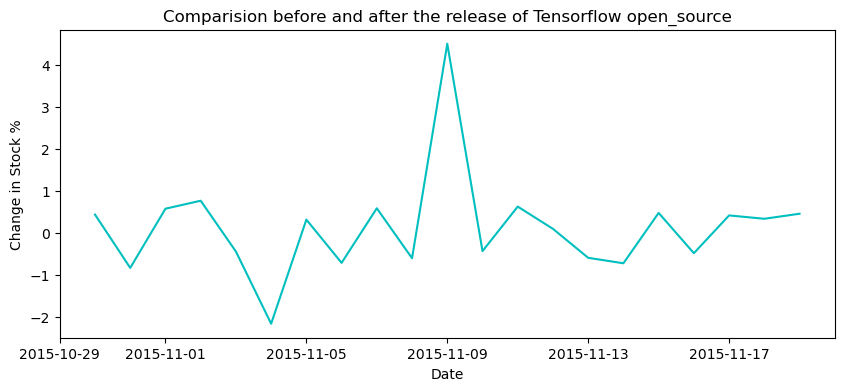

In [56]:
plt.figure(figsize =(10,4))
plt.plot(tf["Date"],tf["Stock_Impact_%"],color="c")
plt.title("Comparision before and after the release of Tensorflow open_source")
plt.xlabel("Date")
plt.ylabel("Change in Stock %")
plt.show()

# 13. Event Study: GPT-4 Release
Similarly, we filter the period when the "GPT-4 release", which made a huge splash in the AI world, occurred. We examine the impact of this launch on the stock market on a timeline.

In [57]:
df[df.Event == "GPT-4 release"] 

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2994,2023-03-14,OpenAI,7.78,4.05,304.57,GPT-4 release,15.2,2023


In [58]:
GPT_4= df.loc[2984:3004]
GPT_4

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
2984,2023-03-04,OpenAI,10.59,4.26,326.43,NaN,-0.28,2023
2985,2023-03-05,OpenAI,8.24,3.58,257.92,NaN,-0.48,2023
2986,2023-03-06,OpenAI,9.32,4.21,320.60,NaN,0.89,2023
2987,2023-03-07,OpenAI,8.52,4.13,313.16,NaN,-0.08,2023
2988,2023-03-08,OpenAI,8.90,3.63,263.03,NaN,-0.56,2023
2989,2023-03-09,OpenAI,8.44,4.64,363.84,NaN,0.91,2023
2990,2023-03-10,OpenAI,9.55,4.83,383.49,NaN,-0.02,2023
2991,2023-03-11,OpenAI,8.34,3.95,294.67,NaN,0.19,2023
2992,2023-03-12,OpenAI,8.71,3.57,256.88,NaN,-0.87,2023
2993,2023-03-13,OpenAI,10.61,5.19,419.06,NaN,0.53,2023


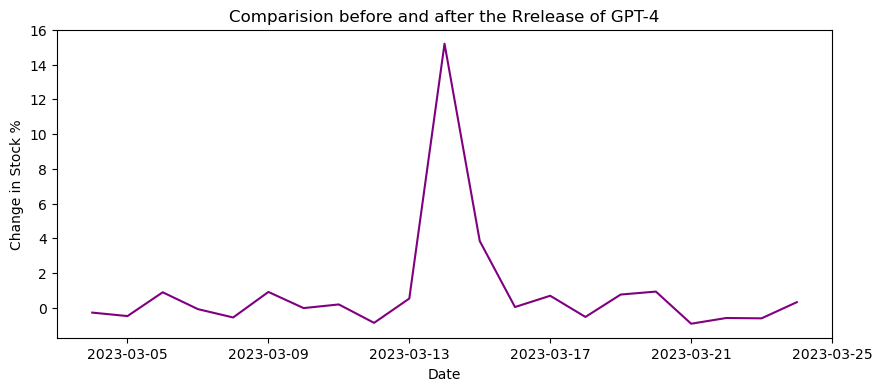

In [59]:
plt.figure(figsize =(10,4))
plt.plot(GPT_4["Date"],GPT_4["Stock_Impact_%"],color="purple")
plt.title("Comparision before and after the Rrelease of GPT-4")
plt.xlabel("Date")
plt.ylabel("Change in Stock %")
plt.show()

# 14. Statistical Summaries by Company
We create summary tables by grouping the companies' average stock impact, average R&D spending, and maximum stock values reached.

In [60]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [61]:
df.groupby("Company")["Stock_Impact_%"].mean()

Company
Google    0.026209
Meta      0.009762
OpenAI    0.040709
Name: Stock_Impact_%, dtype: float64

In [62]:
df.groupby("Company")["R&D_Spending_USD_Mn"].mean() #expenditure

Company
Google    115.888623
Meta       72.415294
OpenAI      7.249595
Name: R&D_Spending_USD_Mn, dtype: float64

In [63]:
df.groupby("Company")["Stock_Impact_%"].max()

Company
Google     6.2
Meta       7.4
OpenAI    18.5
Name: Stock_Impact_%, dtype: float64

# 15. Maximum Stock Impact by Year and Company
Finally, by grouping by both Year and Company, we find the highest stock impact for each year. We visualize this with a horizontal bar chart (`barh`) to see which company peaked in which year.

In [64]:
df.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015


In [65]:
stocks=df.groupby(["Year","Company"])["Stock_Impact_%"].max()
stocks

Year  Company
2015  Google      4.96
      Meta        4.80
      OpenAI      3.92
2016  Google      6.20
      Meta        2.14
      OpenAI      4.66
2017  Google      4.42
      Meta        4.21
      OpenAI      4.63
2018  Google      1.97
      Meta        4.54
      OpenAI      4.94
2019  Google      3.20
      Meta        1.86
      OpenAI      4.20
2020  Google      4.18
      Meta        4.86
      OpenAI      8.50
2021  Google      4.10
      Meta        4.80
      OpenAI      7.20
2022  Google      4.88
      Meta        3.98
      OpenAI     12.00
2023  Google      5.80
      Meta        6.80
      OpenAI     15.20
2024  Google      2.89
      Meta        7.40
      OpenAI     18.50
Name: Stock_Impact_%, dtype: float64

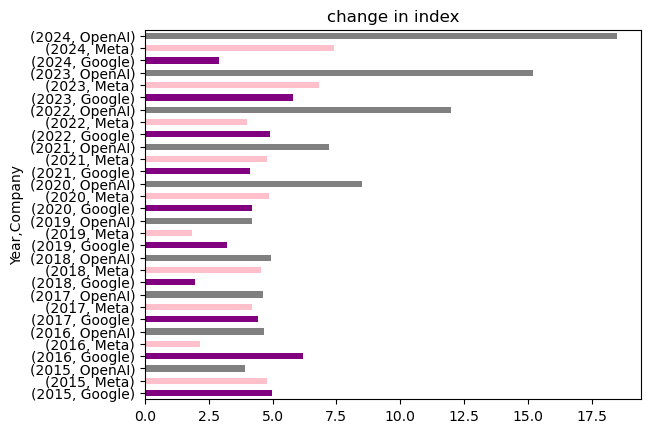

In [66]:
stocks.plot(kind="barh",color=["purple","pink","grey"])
plt.title("change in index")
plt.show()
